In [1]:
from quark import Task
token = 'Please Insert your token here (SQC Lab - Quafu)'
tmgr = Task(token)
tmgr.status()

{'Baihua': 3,
 'Yudu': 'Calibrating',
 'Dongling': 2,
 'Haituo': 'Calibrating',
 'Baiwang': 15,
 'Fenghuang': 1,
 'Haituo-2': 'Maintenance',
 'Hongluo': 'Calibrating',
 'Jiu': 'Maintenance',
 'Ling': 'Maintenance',
 'Lingkai-1': 'Calibrating',
 'Lingkai-2': 'Calibrating',
 'Miaofeng': 'Maintenance',
 'Shenglian': 'Calibrating',
 'Xiang': 'Maintenance'}

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quafu import QuantumCircuit, simulate

In [3]:
# 1. Creating QFT and IQFT Functions

def apply_qft(circuit, qubits):
    n = len(qubits)
    for i in range(n):
        circuit.h(qubits[i])
        for j in range(i + 1, n):
            theta = np.pi / (2**(j - i))
            circuit.cp(qubits[j], qubits[i], theta)

def apply_iqft(circuit, qubits):
    n = len(qubits)
    for i in range(n - 1, -1, -1):
        for j in range(n - 1, i, -1):
            theta = -np.pi / (2**(j - i))
            circuit.cp(qubits[j], qubits[i], theta)
        circuit.h(qubits[i])

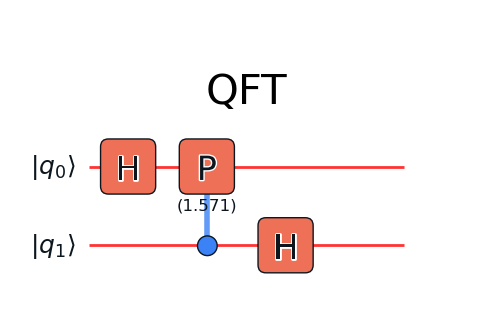

In [4]:
# QFT Circuit Diagram

q_list = [0, 1]
qc = QuantumCircuit(2)
apply_qft(qc, q_list)
qc.plot_circuit(title='QFT')

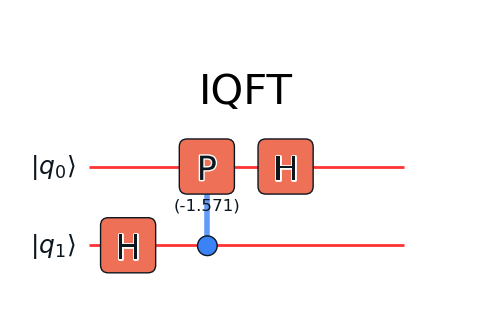

In [5]:
# IQFT Circuit Diagram

q_list = [0, 1]
qc = QuantumCircuit(2)
apply_iqft(qc, q_list)
qc.plot_circuit(title='IQFT')

In [6]:
# 1. Defining Our Own Permutation Matrix

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

In [7]:
# 2. Preparing the Initial State and Applying Operators

n_qubits = 2
qc = QuantumCircuit(n_qubits)

qc.x(n_qubits-1) # Changing the initial qubit from state |0> to state |1>.

# Applying QFT
apply_qft(qc, [0,1])

# Applying  our operator
qc.unitary(U, [1,0])

# Applying IQFT
apply_iqft(qc, [0,1])

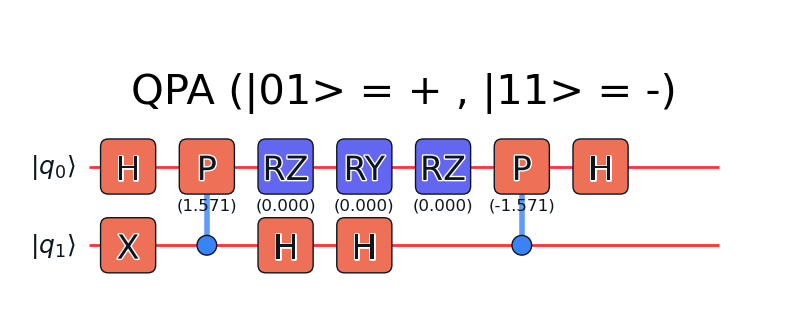

In [8]:
# 3. Drawing circuit diagram

qc.plot_circuit(title="QPA (|01> = + , |11> = -)")

Results (Probabilities):
|01> = + , |11> = -
State |01>: 1.0000


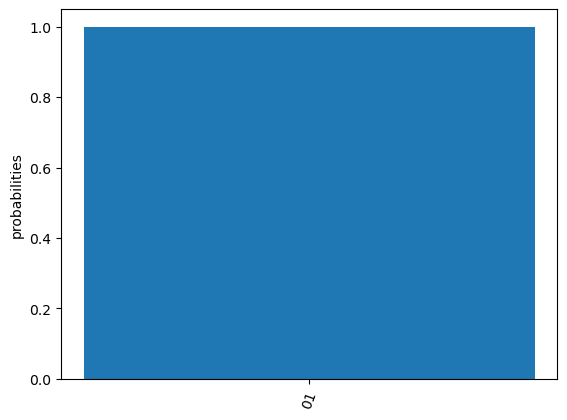

In [9]:
# Simulation, Results and Graph
sim_res = simulate(qc)
probs = sim_res.probabilities

print("Results (Probabilities):")
print("|01> = + , |11> = -")
for i, prob in enumerate(probs):
    if prob > 0.001:
        state = bin(i)[2:].zfill(n_qubits)
        print(f"State |{state}>: {prob:.4f}")

sim_res.plot_probabilities()

In [10]:
# Exporting as OpenQASM

qasm = qc.to_openqasm()
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
x q[1];
h q[0];
cp(1.5707963267948966) q[1],q[0];
h q[1];
rz(0.0) q[0];
ry(0.0) q[0];
rz(0.0) q[0];
h q[1];
cp(-1.5707963267948966) q[1],q[0];
h q[0];



In [11]:
# Preparing the task
task = {'chip': 'Baihua',  # chip name
        'name': 'QPA',  # task name
        'circuit':qasm, # qasm
        'compile':True
        }

In [12]:
# Sending our task to Quafu's quantum computer
tid = tmgr.run(task)

In [14]:
# Task status
tmgr.status(tid)

'Finished'

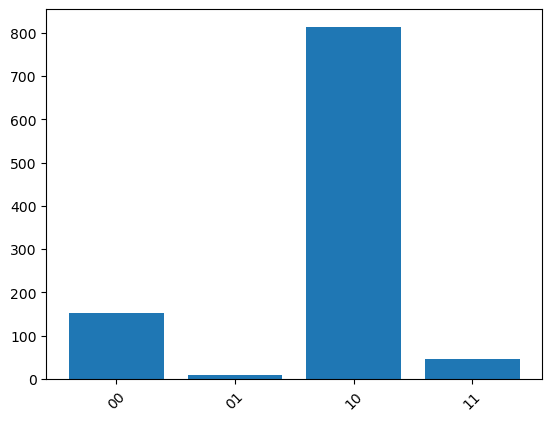

In [15]:
# Graph: The results from quantum computer
res = tmgr.result(tid)
data = res['count']
bases = sorted(data)
count = [data[base] for base in bases]

plt.bar(bases, count)
ticks = plt.xticks(rotation=45)

In [ ]:
# Simulation and quantum computer results provide conflicting information regarding the positions of qubits !!!

In [ ]:
Operator	THE GATES
P0+​	    (Empty Circuit) (I)
P1+​	    CNOT(q1​,q0​), then X(q1​)
P2+​	    X(q0​)
P3+​	    CNOT(q1​,q0​), then X(q1​),X(q0​)    
P0−​	    CNOT(q1​,q0​)
P1−​	    X(q1​)
P2−​	    CNOT(q1​,q0​), then X(q0​)
P3−​	    X(q1​),X(q0​)

In [ ]:
"""

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P1+
U = np.array([
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2+
U = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P3+
U = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0]], dtype=complex)

---------------------------------

#P0-
U = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P1-
U = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2-
U = np.array([
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P3-
U = np.array([
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0]], dtype=complex)

"""